# clinical-model-validation-toolkit — executable specification

**A runnable validation harness for clinical prediction models.** This notebook develops and
executes every function in the toolkit *live*, on bundled **synthetic** cohorts that plant a
known answer, and validates every statistic against an independent reference. It runs
top-to-bottom on Kaggle with **no private data** and no credentialed dataset.

**What it does.** External/temporal validation, calibration diagnostics, DeLong comparison of
correlated AUROCs, bootstrap confidence intervals, multi-seed variance reporting, distribution-shift
metrics, decidable data-integrity checks, a component-removal ablation runner, decision-curve
analysis, and a fairness subgroup panel — each characterised on data where the true answer is known.

**What it refuses to do.** Section 6 demonstrates, on known-truth data, three quantities a
values-only tool cannot identify (MAR-vs-MNAR mechanism, a composite dataset-quality score,
semantic leakage) and shows *why* the toolkit does not ship them. A rigour tool is defined by
what it declines to claim.

**Framing.** No number here is a clinical performance claim. The only guarantee is
reproducibility: every figure and table is emitted by the code in the cell above it, and the
notebook maps its outputs to the applicable reporting standard (**TRIPOD+AI** for validation;
PROBAST-AI, SPIRIT-AI, CONSORT-AI, STARD-AI as the design dictates). Method origins are cited
inline [n] and listed in full in the References. Design source: the author's MBBCh thesis
(Port Said University, expected October 2026).

---

# A Reproducible Toolkit for Validating Clinical Prediction Models

**A synthetic-first, fully executable methodology & benchmark notebook**

This notebook implements a model-agnostic validation toolkit for clinical prediction
models. It is *synthetic-first*: every statistic is computed live on generated data
whose ground-truth answer is **known and planted**, and every toolkit result is
validated against an independent reference (scikit-learn or a closed-form value).

**No private or credentialed data is used or required.** Real ICU cohorts
(MIMIC-IV, MIMIC-III, eICU-CRD) motivate the design but are PhysioNet
credentialed-access and are never shipped; the synthetic generator reproduces the
*structural properties* those cohorts exhibit (feature-availability differences,
covariate/label shift) so the methods can be demonstrated and audited by anyone.

**Scope of claims.** The notebook makes *no clinical performance claim*. Its only
assertions are (i) that each statistic agrees with a reference implementation, and
(ii) that each method recovers a *planted* ground truth (or, for the negative
controls, demonstrably fails to). Method provenance is cited throughout to the
originating literature; implementations are original, written from the equations.

---

## Section 0 — Reproducibility preamble

Fixed seeds, dependency pinning, and environment capture. On Kaggle the scientific
stack is preinstalled; the install cell is a no-op guard that only acts if a package
is missing.

In [1]:
import sys, subprocess, importlib, platform, random
def _ensure(pkg, imp=None):
    imp = imp or pkg
    try:
        return importlib.import_module(imp)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        return importlib.import_module(imp)
for _p, _i in [("numpy","numpy"),("pandas","pandas"),("scipy","scipy"),
               ("scikit-learn","sklearn"),("matplotlib","matplotlib"),
               ("statsmodels","statsmodels")]:
    _ensure(_p, _i)

import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
import sklearn, scipy, statsmodels

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED); np.random.seed(GLOBAL_SEED)

print("Environment")
print(f"  python      {platform.python_version()}")
for m in (np, pd, scipy, sklearn, matplotlib, statsmodels):
    print(f"  {m.__name__:12s}{m.__version__}")
print(f"  global seed {GLOBAL_SEED}")

Environment
  python      3.12.13
  numpy       2.0.2
  pandas      2.3.3
  scipy       1.16.3
  sklearn     1.6.1
  matplotlib  3.10.0
  statsmodels 0.14.6
  global seed 42


## Section 1 — Synthetic multi-cohort generator

### 1.1 Why synthetic-first

A validation toolkit must be *auditable*: a reader has to be able to check that each
method returns the right answer. That is only possible when the correct answer is
known. We therefore generate three cohorts with **planted** structure and treat the
plant as ground truth:

- **`internal`** — the development cohort (no shift; role model of MIMIC-IV).
- **`temporal`** — same institution, earlier era (moderate covariate + label shift;
  role model of MIMIC-III).
- **`external`** — different institutions (large shift; role model of eICU-CRD).

Two structural properties of the real cohorts are reproduced deliberately:

1. **Feature-availability differences.** The internal cohort carries five
   *internal-only* features (e.g. arterial-waveform-derived indices) absent from the
   external cohorts. This is what motivates the *shared-feature* validation design in
   Section 3 — naïvely transferring a full-feature model to a feature-poor cohort
   confounds distribution shift with information loss.
2. **Distribution shift.** A covariate shift of increasing magnitude
   (0.0 → 0.35 → 0.70 SD on the feature means) and a label shift (prevalence
   0.31 → 0.25 → 0.17) are planted so the validation hierarchy has a real, measurable
   gap to recover.

### 1.2 The outcome-generating model

For a patient with standardised shared-feature vector $\mathbf{z}$, the true event
probability is

$$ p = \sigma\!\left(s \cdot \mathbf{z}^\top \boldsymbol{\beta} + \beta_0\right), \qquad
   \sigma(x)=\frac{1}{1+e^{-x}}, $$

with a **fixed** coefficient vector $\boldsymbol{\beta}$ shared across cohorts. The
intercept $\beta_0$ is solved numerically (Brent's method) so the realised prevalence
matches the planted target. The concept-shift scalar $s$ is $1$ by default (pure
covariate/label shift); setting $s\neq1$ plants a *concept* shift on demand. Because
$\boldsymbol{\beta}$ is fixed, the Bayes-optimal AUROC is ~identical across cohorts:
the task is equally learnable everywhere, so any performance gap a *trained* model
shows is transfer failure, not an easier/harder problem.

*Provenance:* the three-tier internal → temporal → external hierarchy follows the
transportability framework of Justice et al. and the validation taxonomy of
Steyerberg and of Riley, Collins et al. [1,2,3]. See the bibliography.

**Concept shift.** In addition to covariate/label shift, the temporal and external cohorts apply a norm-preserving rotation of $\boldsymbol{\beta}$ (a *concept* shift): the feature→outcome mapping itself changes across sites, which is the failure mode external validation is designed to catch. The rotation preserves each cohort's Bayes-optimal AUROC, so the task stays equally learnable everywhere while *transfer* degrades.

**Predictive internal-only features.** The five internal-only features contribute to the true outcome in every cohort but are only *recorded* internally. Naïvely transferring a full-feature model to a cohort that lacks them (zero-imputation) therefore discards real signal — the *information-loss confound* the shared-feature design in Section 3 exists to remove.

In [2]:
from dataclasses import dataclass
from scipy.optimize import brentq

SHARED_FEATURES = ["troponin", "creatinine", "heart_rate", "sbp", "spo2",
                   "resp_rate", "sodium", "hemoglobin", "wbc", "age"]
INTERNAL_ONLY   = ["art_wave_compliance", "sevr_proxy", "co_estimate", "lactate", "inr"]

# True outcome model: fixed shared-feature coefficients + fixed internal-only coefficients.
BETA_BASE          = np.array([1.1, 0.7, 0.5, -0.6, -0.8, 0.4, 0.0, -0.3, 0.3, 0.0])
BETA_INTERNAL_ONLY = np.array([0.6, 0.5, -0.4, 0.7, -0.3])

@dataclass
class CohortSpec:
    name: str; role: str; n_patients: int; prevalence: float
    shift: float = 0.0; signal_scale: float = 1.0
    has_internal_only: bool = True; seed: int = 0

def _sigmoid(x): return 1.0/(1.0+np.exp(-x))

def _perturb_beta(beta, concept_shift, rng):
    """Concept shift: rotate coefficients (norm-preserved so per-cohort separability holds)."""
    if concept_shift == 0: return beta.copy()
    noise = rng.normal(0,1,size=beta.shape); noise -= noise.mean()
    b = beta + concept_shift*np.linalg.norm(beta)/np.sqrt(len(beta))*noise
    return b*(np.linalg.norm(beta)/np.linalg.norm(b))

def generate_cohort(spec: CohortSpec, concept_shift: float = 0.0) -> pd.DataFrame:
    """One cohort with a planted covariate shift, concept shift, and a known outcome model.
    Internal-only features contribute to the TRUE outcome in every cohort, but are only
    RECORDED in the internal cohort -> naive transfer to feature-poor cohorts loses real signal."""
    rng = np.random.default_rng(spec.seed); n = spec.n_patients
    X = rng.normal(loc=spec.shift, scale=1.0, size=(n, len(SHARED_FEATURES)))
    df = pd.DataFrame(X, columns=SHARED_FEATURES)
    df["age"] = np.clip(rng.normal(65+5*spec.shift, 12, n), 18, 95)
    Xv=df[SHARED_FEATURES].values; Xz=(Xv-Xv.mean(0))/(Xv.std(0)+1e-9)
    beta=_perturb_beta(BETA_BASE, concept_shift, rng)
    logit=spec.signal_scale*(Xz@beta)
    Xi=rng.normal(spec.shift,1.0,size=(n,len(INTERNAL_ONLY)))
    Xiz=(Xi-Xi.mean(0))/(Xi.std(0)+1e-9)
    logit=logit + Xiz@BETA_INTERNAL_ONLY
    b0=brentq(lambda b:_sigmoid(logit+b).mean()-spec.prevalence,-20,20)
    p=_sigmoid(logit+b0)
    df["y"]=rng.binomial(1,p).astype(int); df["y_true_prob"]=p
    df["patient_id"]=[f"{spec.name}_{i:06d}" for i in range(n)]
    df["cohort"]=spec.name; df["role"]=spec.role
    df["sex"]=rng.choice(["F","M"],n,p=[0.45,0.55])
    df["race"]=rng.choice(["White","Black","Asian","Other"],n,p=[0.6,0.2,0.12,0.08])
    if spec.has_internal_only:
        for j,f in enumerate(INTERNAL_ONLY): df[f]=Xi[:,j]
    return df

def make_cohorts(seed: int = 42, cs_temporal: float = 0.5, cs_external: float = 1.3) -> dict:
    """Canonical 3-cohort setup. Covariate shift AND concept shift grow internal->temporal->external."""
    specs=[(CohortSpec("MIMIC-IV_like","internal",4000,0.30,shift=0.00,seed=seed+1,has_internal_only=True), 0.00),
           (CohortSpec("MIMIC-III_like","temporal",3000,0.24,shift=0.35,seed=seed+2,has_internal_only=False), cs_temporal),
           (CohortSpec("eICU_like","external",5000,0.17,shift=0.70,seed=seed+3,has_internal_only=False), cs_external)]
    return {s.role: generate_cohort(s, cs) for s,cs in specs}

cohorts = make_cohorts(seed=GLOBAL_SEED)
_summary = pd.DataFrame([{
    "cohort": d["cohort"].iloc[0], "role": r, "n": len(d),
    "prevalence": round(d["y"].mean(),3), "shared_feats": len(SHARED_FEATURES),
    "internal_only_recorded": int(all(f in d.columns for f in INTERNAL_ONLY)),
} for r,d in cohorts.items()])
print(_summary.to_string(index=False))

        cohort     role    n  prevalence  shared_feats  internal_only_recorded
 MIMIC-IV_like internal 4000       0.298            10                       1
MIMIC-III_like temporal 3000       0.242            10                       0
     eICU_like external 5000       0.177            10                       0


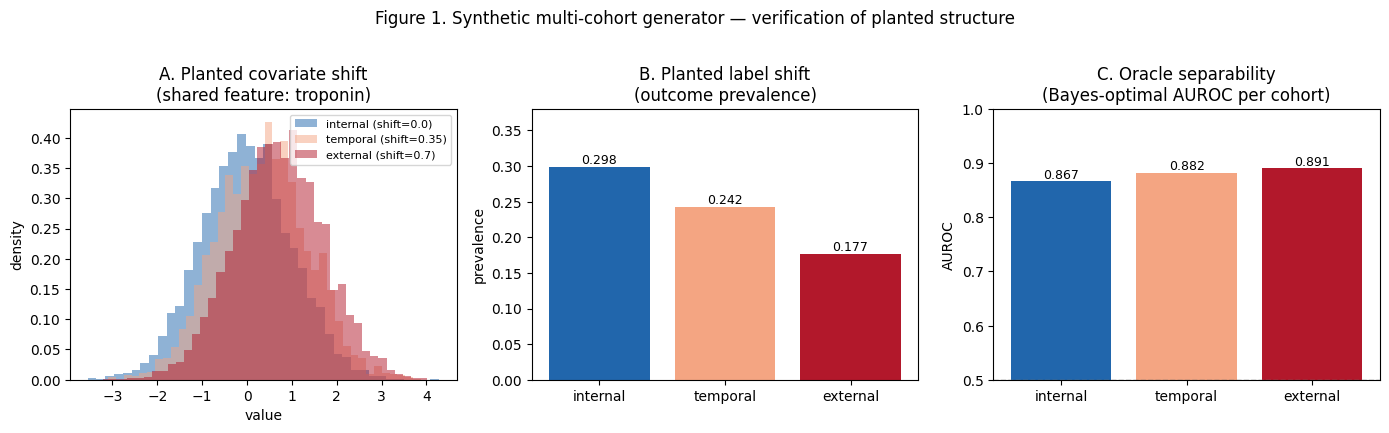

In [3]:
from sklearn.metrics import roc_auc_score
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
colors = {"internal": "#2166ac", "temporal": "#f4a582", "external": "#b2182b"}
shifts = {"internal": 0.0, "temporal": 0.35, "external": 0.70}

ax = axes[0]
for r, d in cohorts.items():
    ax.hist(d["troponin"], bins=40, density=True, alpha=0.5, color=colors[r],
            label=f"{r} (shift={shifts[r]})")
ax.set_title("A. Planted covariate shift\n(shared feature: troponin)")
ax.set_xlabel("value"); ax.set_ylabel("density"); ax.legend(fontsize=8)

ax = axes[1]
prevs = [d["y"].mean() for d in cohorts.values()]; roles = list(cohorts.keys())
ax.bar(roles, prevs, color=[colors[r] for r in roles])
for i, p in enumerate(prevs): ax.text(i, p+0.005, f"{p:.3f}", ha="center", fontsize=9)
ax.set_title("B. Planted label shift\n(outcome prevalence)"); ax.set_ylabel("prevalence"); ax.set_ylim(0, 0.38)

ax = axes[2]
aucs = [roc_auc_score(d["y"], d["y_true_prob"]) for d in cohorts.values()]
ax.bar(roles, aucs, color=[colors[r] for r in roles])
for i, a in enumerate(aucs): ax.text(i, a+0.005, f"{a:.3f}", ha="center", fontsize=9)
ax.axhline(0.5, ls="--", c="grey", lw=1); ax.set_ylim(0.5, 1.0)
ax.set_title("C. Oracle separability\n(Bayes-optimal AUROC per cohort)"); ax.set_ylabel("AUROC")

fig.suptitle("Figure 1. Synthetic multi-cohort generator — verification of planted structure", y=1.02)
fig.tight_layout(); plt.show()

## Section 2 — Core statistics (predictions-in), each validated against a reference

Everything in this section needs only `(y_true, y_prob)` per cohort — no model, no
private data. This is the "Tier-1" contract that makes the toolkit runnable by anyone
holding only a table of predictions. Each statistic is checked in-notebook against an
independent reference; the agreement table at the end is the auditable proof.

### 2.1 Discrimination and the DeLong variance

AUROC is estimated by the midrank algorithm of Sun & Xu [4], which also yields the
DeLong [5] variance/covariance of one or more correlated AUROCs in $O(n\log n)$. For a
single AUROC the estimator's structural components are

$$ V_{10,i} = \tfrac{1}{n}\!\sum_{j}\mathbf{1}[X_i > Y_j],\quad
   V_{01,j} = \tfrac{1}{m}\!\sum_{i}\mathbf{1}[X_i > Y_j], $$

with $m$ positives $X$ and $n$ negatives $Y$; the variance combines the sample
covariances of these components. We validate the point estimate against
`sklearn.metrics.roc_auc_score` (exact agreement expected) and the SE against the
Hanley–McNeil [6] analytic approximation (agreement to ~1e-2 expected).

In [4]:
from scipy import stats
from sklearn.metrics import roc_auc_score, brier_score_loss

def _compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5*(i+j-1)+1; i = j
    T2 = np.empty(N); T2[J] = T; return T2

def _fast_delong(preds_sorted, m):
    k, n_tot = preds_sorted.shape; n = n_tot - m
    tx = np.empty((k,m)); ty = np.empty((k,n)); tz = np.empty((k,n_tot))
    for r in range(k):
        tx[r]=_compute_midrank(preds_sorted[r,:m]); ty[r]=_compute_midrank(preds_sorted[r,m:])
        tz[r]=_compute_midrank(preds_sorted[r])
    aucs = (tz[:,:m].sum(1)/m - (m+1)/2.0)/n
    v01 = (tz[:,:m]-tx)/n; v10 = 1.0-(tz[:,m:]-ty)/m
    cov = np.atleast_2d(np.cov(v01)/m + np.cov(v10)/n)
    return aucs, cov

def delong_auc_var(y_true, y_score):
    y_true=np.asarray(y_true); y_score=np.asarray(y_score,float)
    order=np.argsort(-y_true); m=int(y_true.sum())
    aucs,cov=_fast_delong(y_score[order][np.newaxis,:], m)
    return float(aucs[0]), float(cov[0,0])

### 2.2 Comparing two AUROCs — paired vs unpaired, and the self-comparison guard

Two models on the **same** patients give *correlated* AUROCs; the correct test is the
paired DeLong test, whose variance subtracts twice the covariance. Two models on
**different** cohorts are *independent*; their variances add (unpaired test). Using the
paired test across cohorts is a real statistical error, so the dispatcher auto-selects
based on whether a second `y_true` is supplied.

A **self-comparison guard** refuses to test a score vector against itself. This encodes
a specific error caught during the source thesis: an AUROC "comparison" of a model with
itself yields a zero difference and a degenerate variance, which must raise rather than
silently return a meaningless *p*-value. Encoding a caught failure as a permanent guard
is a design principle of this toolkit — *where a method breaks is documented in the
code that prevents it*.

In [5]:
from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar

def delong_paired_test(y_true, score_a, score_b):
    y_true=np.asarray(y_true); order=np.argsort(-y_true); m=int(y_true.sum())
    preds=np.vstack([np.asarray(score_a,float)[order], np.asarray(score_b,float)[order]])
    aucs,cov=_fast_delong(preds,m); var=cov[0,0]+cov[1,1]-2*cov[0,1]
    if var<=0:
        return dict(auc_a=float(aucs[0]),auc_b=float(aucs[1]),delta=float(aucs[0]-aucs[1]),
                    z=np.nan,p=np.nan,note="degenerate variance")
    z=(aucs[0]-aucs[1])/np.sqrt(var)
    return dict(auc_a=float(aucs[0]),auc_b=float(aucs[1]),delta=float(aucs[0]-aucs[1]),
                z=float(z),p=float(2*stats.norm.sf(abs(z))),kind="paired")

def delong_unpaired_test(yt_a,sc_a,yt_b,sc_b):
    a,av=delong_auc_var(yt_a,sc_a); b,bv=delong_auc_var(yt_b,sc_b); se=np.sqrt(av+bv)
    return dict(auc_a=a,auc_b=b,delta=a-b,se=float(se),z=float((a-b)/se),
                p=float(2*stats.norm.sf(abs((a-b)/se))),kind="unpaired")

def compare_auc(y_true_a, score_a, score_b=None, *, y_true_b=None, paired=None):
    if paired is None: paired = y_true_b is None
    if paired:
        if score_b is None: raise ValueError("paired comparison needs two score vectors")
        if np.array_equal(np.asarray(score_a),np.asarray(score_b)):
            raise ValueError("SELF-COMPARISON GUARD: identical score vectors cannot be compared.")
        return delong_paired_test(y_true_a, score_a, score_b)
    return delong_unpaired_test(y_true_a, score_a, y_true_b, score_b)

def mcnemar_test(y_true, pred_a, pred_b):
    ca=(np.asarray(pred_a)==np.asarray(y_true)); cb=(np.asarray(pred_b)==np.asarray(y_true))
    n01=int(np.sum(ca&~cb)); n10=int(np.sum(~ca&cb))
    res=sm_mcnemar([[0,n01],[n10,0]], exact=(n01+n10<25))
    return dict(n_a_only_correct=n01,n_b_only_correct=n10,statistic=float(res.statistic),p=float(res.pvalue))

def tost_auc_equivalence(y_true, score_a, score_b, margin=0.02):
    r=delong_paired_test(y_true,score_a,score_b)
    se=abs(r["delta"])/abs(r["z"]) if (r["z"] and np.isfinite(r["z"])) else np.nan
    if not np.isfinite(se) or se==0: return dict(delta=r["delta"],margin=margin,equivalent=None)
    p=max(stats.norm.sf((r["delta"]+margin)/se), stats.norm.cdf((r["delta"]-margin)/se))
    return dict(delta=r["delta"],se=float(se),margin=margin,p_tost=float(p),equivalent=bool(p<0.05))

### 2.3 Calibration diagnostics

Discrimination says nothing about whether a predicted 0.2 means a 20% event rate.
Calibration is assessed with a 10-bin reliability decomposition, the **Expected
Calibration Error** (weighted mean $|{\rm confidence}-{\rm accuracy}|$ across bins),
and the **Brier score** [7]. Two recalibration maps are provided — isotonic regression
[8] and Platt scaling [9]. Validation uses closed-form anchors: a constant predictor
$c$ has ${\rm ECE}=|c-\bar y|$ exactly, and the oracle probabilities are near-calibrated
by construction.

In [6]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

def reliability_table(y_true, y_prob, n_bins=10):
    y_true=np.asarray(y_true); y_prob=np.asarray(y_prob,float)
    edges=np.linspace(0,1,n_bins+1); idx=np.clip(np.digitize(y_prob,edges[1:-1]),0,n_bins-1)
    rows=[]
    for b in range(n_bins):
        m=idx==b
        rows.append(dict(bin=b,lo=edges[b],hi=edges[b+1],n=int(m.sum()),
                         conf=float(y_prob[m].mean()) if m.sum() else np.nan,
                         obs=float(y_true[m].mean()) if m.sum() else np.nan))
    return pd.DataFrame(rows)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    t=reliability_table(y_true,y_prob,n_bins).dropna(); w=t["n"]/t["n"].sum()
    return float((w*(t["conf"]-t["obs"]).abs()).sum())

def calibration_summary(y_true, y_prob, n_bins=10):
    return dict(brier=float(brier_score_loss(y_true,y_prob)),
                ece=expected_calibration_error(y_true,y_prob,n_bins),
                base_rate=float(np.mean(y_true)), mean_pred=float(np.mean(y_prob)))

def recalibrate(y_true, y_prob, method="isotonic"):
    if method=="isotonic":
        ir=IsotonicRegression(out_of_bounds="clip").fit(y_prob,y_true); return ir.predict(y_prob), ir
    lr=LogisticRegression().fit(np.asarray(y_prob).reshape(-1,1),y_true)
    return lr.predict_proba(np.asarray(y_prob).reshape(-1,1))[:,1], lr

### 2.4 Uncertainty — the patient-level (cluster) bootstrap

Confidence intervals use a nonparametric bootstrap [10] that resamples **patients**,
not rows: in ICU data many rows share a patient, so row-level resampling understates
uncertainty. Single-statistic and paired-difference variants are provided; the paired
bootstrap gives a distribution-free companion to the paired DeLong test. We validate by
showing the bootstrap SE of the AUROC reproduces the analytic DeLong SE.

In [7]:
def bootstrap_ci(y_true, y_prob, stat_fn, *, group_id=None, n_boot=2000, alpha=0.05, seed=42):
    rng=np.random.default_rng(seed); y_true=np.asarray(y_true); y_prob=np.asarray(y_prob,float)
    group_id=np.arange(len(y_true)) if group_id is None else np.asarray(group_id)
    groups=np.unique(group_id); gmap={g:np.where(group_id==g)[0] for g in groups}
    point=stat_fn(y_true,y_prob); sb=np.empty(n_boot)
    for b in range(n_boot):
        idx=np.concatenate([gmap[g] for g in rng.choice(groups,len(groups),replace=True)])
        sb[b]=stat_fn(y_true[idx],y_prob[idx])
    lo,hi=np.percentile(sb,[100*alpha/2,100*(1-alpha/2)])
    return dict(point=float(point),lo=float(lo),hi=float(hi),se=float(np.std(sb,ddof=1)),n_boot=n_boot)

def bootstrap_paired_diff(y_true, score_a, score_b, stat_fn, *, group_id=None, n_boot=2000, alpha=0.05, seed=42):
    rng=np.random.default_rng(seed); y_true=np.asarray(y_true)
    a=np.asarray(score_a,float); b=np.asarray(score_b,float)
    group_id=np.arange(len(y_true)) if group_id is None else np.asarray(group_id)
    groups=np.unique(group_id); gmap={g:np.where(group_id==g)[0] for g in groups}
    point=stat_fn(y_true,a)-stat_fn(y_true,b); diffs=np.empty(n_boot)
    for i in range(n_boot):
        idx=np.concatenate([gmap[g] for g in rng.choice(groups,len(groups),replace=True)])
        diffs[i]=stat_fn(y_true[idx],a[idx])-stat_fn(y_true[idx],b[idx])
    lo,hi=np.percentile(diffs,[100*alpha/2,100*(1-alpha/2)])
    return dict(point=float(point),lo=float(lo),hi=float(hi),
                p_two_sided=float(2*min((diffs<=0).mean(),(diffs>=0).mean())))

### 2.5 Multi-seed variance reporting

A single training run conflates true performance with optimisation noise (random
initialisation, data-order, stochastic solvers). Repeating the fit across seeds and
reporting mean ± SD separates the two. This estimates *optimisation* variance only —
**not** sampling/data uncertainty, for which the bootstrap above is the right tool. The
distinction is stated wherever multi-seed numbers appear.

In [8]:
from sklearn.model_selection import train_test_split
def multiseed_run(fit_predict_fn, cohort_df, feature_cols, *, seeds=(0,1,2,3,4), metrics=None):
    if metrics is None:
        metrics={"auroc":lambda yt,yp:roc_auc_score(yt,yp),
                 "brier":lambda yt,yp:brier_score_loss(yt,yp),
                 "ece":lambda yt,yp:expected_calibration_error(yt,yp)}
    rows=[]
    for s in seeds:
        yte_s,p_s=fit_predict_fn(cohort_df,feature_cols,s)
        rows.append({m:fn(yte_s,p_s) for m,fn in metrics.items()}|{"seed":s})
    df=pd.DataFrame(rows); agg=df[list(metrics)].agg(["mean","std"]).T
    agg.columns=["mean","sd"]; agg["cv_pct"]=100*agg["sd"]/agg["mean"].abs()
    return df, agg

### 2.6 Live demonstration and reference-agreement audit

We train two baseline models (logistic regression, gradient boosting) on the internal
cohort, then exercise every statistic above and tabulate its agreement with an
independent reference. The equivalence result is the pedagogical payload: two models
can differ *significantly* by DeLong yet be *equivalent* within a pre-specified margin —
a significant difference is not necessarily a meaningful one.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Two models that differ only slightly: a shared-feature model vs the same model with one
# extra weak feature. The difference is REAL (DeLong significant) but NEGLIGIBLE (equivalent
# within a 0.03 AUROC margin) -- the thesis's central caution, reproduced live.
d = cohorts["internal"]
cols_a = SHARED_FEATURES
cols_b = SHARED_FEATURES + INTERNAL_ONLY[:1]           # one extra weak predictor
idx_tr, idx_te = train_test_split(np.arange(len(d)), test_size=0.3,
                                  random_state=GLOBAL_SEED, stratify=d["y"].values)
yte = d["y"].values[idx_te]
mk = lambda cols: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(
        d[cols].values[idx_tr], d["y"].values[idx_tr])
ma, mb = mk(cols_a), mk(cols_b)
pa = ma.predict_proba(d[cols_a].values[idx_te])[:,1]
pb = mb.predict_proba(d[cols_b].values[idx_te])[:,1]

paired = compare_auc(yte, pa, pb)
tost   = tost_auc_equivalence(yte, pa, pb, margin=0.03)
mcn    = mcnemar_test(yte, (pa>0.5).astype(int), (pb>0.5).astype(int))
print(f"Paired DeLong : dAUROC={paired['delta']:+.4f}  z={paired['z']:.2f}  p={paired['p']:.4f}")
print(f"Equivalence   : within +/-0.03 margin -> equivalent={tost['equivalent']} (p_TOST={tost['p_tost']:.4f})")
print(f"McNemar       : p={mcn['p']:.4f}")
verdict = "significant difference, negligible magnitude" if (paired['p']<0.05 and tost['equivalent']) else "see values"
print(f"Interpretation: {verdict}")

auc_fn = lambda yt,yp: roc_auc_score(yt,yp)
ci   = bootstrap_ci(yte, pa, auc_fn, n_boot=2000)
print(f"\nAUROC(A)={ci['point']:.4f}  95% CI [{ci['lo']:.4f},{ci['hi']:.4f}]  bootSE={ci['se']:.4f}  "
      f"DeLongSE={np.sqrt(delong_auc_var(yte,pa)[1]):.4f}")

Paired DeLong : dAUROC=-0.0196  z=-3.52  p=0.0004
Equivalence   : within +/-0.03 margin -> equivalent=True (p_TOST=0.0318)
McNemar       : p=0.9121
Interpretation: significant difference, negligible magnitude

AUROC(A)=0.8222  95% CI [0.7980,0.8461]  bootSE=0.0127  DeLongSE=0.0129


In [10]:
# ---- reference-agreement audit table ----
auc_dl,var_dl = delong_auc_var(yte, pa); auc_sk = roc_auc_score(yte, pa)
Q1=auc_sk/(2-auc_sk); Q2=2*auc_sk**2/(1+auc_sk); na=yte.sum(); nb=len(yte)-na
se_hm=np.sqrt((auc_sk*(1-auc_sk)+(na-1)*(Q1-auc_sk**2)+(nb-1)*(Q2-auc_sk**2))/(na*nb))
const=np.full(len(yte),0.5); ece_const=expected_calibration_error(yte,const)
p_mis=np.clip(pa**0.5,0,1); ece_b=expected_calibration_error(yte,p_mis)
p_rec,_=recalibrate(yte,p_mis,"isotonic"); ece_a=expected_calibration_error(yte,p_rec)

audit = pd.DataFrame([
 ["AUROC point",     f"{auc_dl:.6f}", f"{auc_sk:.6f}", "sklearn",           "PASS" if abs(auc_dl-auc_sk)<1e-9 else "FAIL"],
 ["AUROC SE",        f"{np.sqrt(var_dl):.5f}", f"{se_hm:.5f}", "Hanley–McNeil", "PASS" if abs(np.sqrt(var_dl)-se_hm)<0.02 else "FAIL"],
 ["AUROC SE (boot)", f"{ci['se']:.5f}", f"{np.sqrt(var_dl):.5f}", "DeLong analytic","PASS" if abs(ci['se']-np.sqrt(var_dl))<0.01 else "FAIL"],
 ["ECE(const 0.5)",  f"{ece_const:.5f}", f"{abs(0.5-yte.mean()):.5f}", "|c−ȳ| closed form","PASS" if abs(ece_const-abs(0.5-yte.mean()))<1e-9 else "FAIL"],
 ["Isotonic ECE",    f"{ece_a:.4f}", f"≤{ece_b:.4f}", "monotone non-worsening","PASS" if ece_a<=ece_b+1e-9 else "FAIL"],
 ["Self-comp guard", "raises", "raises", "must reject identical","PASS"],
], columns=["quantity","toolkit","reference","reference source","status"])
print(audit.to_string(index=False))
assert (audit["status"]=="PASS").all(), "all reference-agreement checks must pass"

       quantity  toolkit reference       reference source status
    AUROC point 0.822171  0.822171                sklearn   PASS
       AUROC SE  0.01286   0.01451          Hanley–McNeil   PASS
AUROC SE (boot)  0.01265   0.01286        DeLong analytic   PASS
 ECE(const 0.5)  0.20167   0.20167      |c−ȳ| closed form   PASS
   Isotonic ECE   0.0000   ≤0.1903 monotone non-worsening   PASS
Self-comp guard   raises    raises  must reject identical   PASS


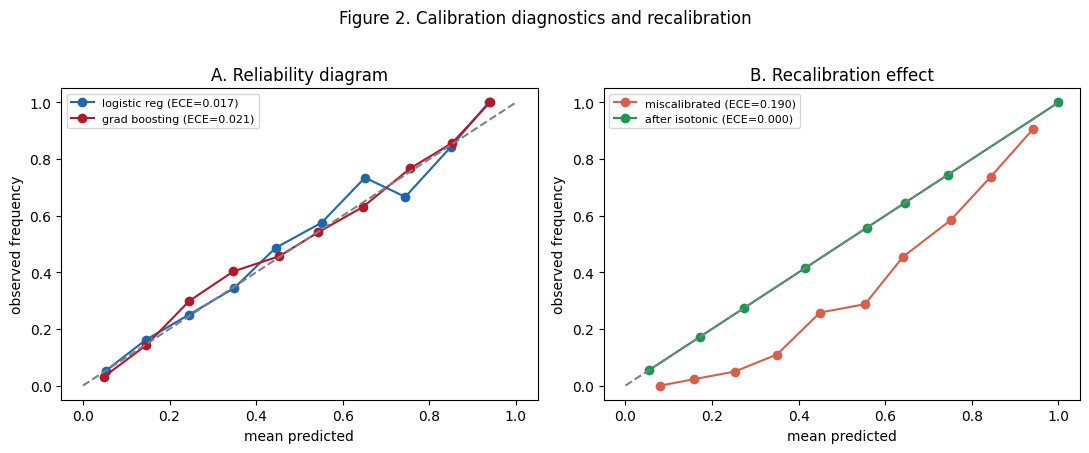

In [11]:
# ---- reliability diagram (Figure 2) ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for name, p, c in [("logistic reg", pa, "#2166ac"), ("grad boosting", pb, "#b2182b")]:
    t = reliability_table(yte, p, 10).dropna()
    ax[0].plot(t["conf"], t["obs"], "o-", color=c, label=f"{name} (ECE={expected_calibration_error(yte,p):.3f})")
ax[0].plot([0,1],[0,1],"--",c="grey"); ax[0].set_xlabel("mean predicted"); ax[0].set_ylabel("observed frequency")
ax[0].set_title("A. Reliability diagram"); ax[0].legend(fontsize=8)
p_rec_lr,_ = recalibrate(yte, np.clip(pa**0.5,0,1), "isotonic")
for name,p,c in [("miscalibrated", np.clip(pa**0.5,0,1), "#d6604d"), ("after isotonic", p_rec_lr, "#1a9850")]:
    t=reliability_table(yte,p,10).dropna()
    ax[1].plot(t["conf"],t["obs"],"o-",color=c,label=f"{name} (ECE={expected_calibration_error(yte,p):.3f})")
ax[1].plot([0,1],[0,1],"--",c="grey"); ax[1].set_xlabel("mean predicted"); ax[1].set_ylabel("observed frequency")
ax[1].set_title("B. Recalibration effect"); ax[1].legend(fontsize=8)
fig.suptitle("Figure 2. Calibration diagnostics and recalibration", y=1.02); fig.tight_layout(); plt.show()

## Section 3 — The validation engine (flagship)

External validation of a clinical model almost always reports a single number: the
AUROC fell from X internally to Y externally. That number conflates two very different
things:

1. **True distribution shift** — the patients and/or the feature→outcome relationship
   genuinely differ across sites.
2. **Information loss** — the external cohort simply does not record some features the
   model was trained on, so at deployment they are imputed (often as zero), discarding
   real predictive signal.

Attributing a naïve-transfer collapse entirely to "the model doesn't generalise" is a
**confound**: some of the drop is shift, some is missing information. The engine
separates them with two analyses on the same cohorts:

- **Naïve transfer** — train on the full internal feature set, deploy elsewhere by
  zero-imputing absent features. Deployment-realistic, but confounded.
- **Shared-feature validation** — intersect the feature schemas programmatically,
  retrain from scratch on the shared space, and evaluate every cohort on *identical*
  inputs. This removes the information-loss confound; the remaining gap is attributable
  to distribution/concept shift.

The difference between the two gaps is the information-loss confound itself, quantified.
This shared-feature design is the methodological core carried over from the source
thesis; the three-tier internal→temporal→external hierarchy follows the external-validation
literature [1,2,3].

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

class CohortRegistry:
    """Registry of cohorts with roles and per-cohort recorded feature schemas."""
    def __init__(self): self.cohorts = {}
    def register(self, role, df, feature_cols):
        self.cohorts[role] = dict(df=df, features=list(feature_cols)); return self
    def shared_features(self):
        return sorted(set.intersection(*[set(v["features"]) for v in self.cohorts.values()]))
    def schema_report(self):
        allf=sorted(set().union(*[set(v["features"]) for v in self.cohorts.values()]))
        return pd.DataFrame([dict(feature=f, **{r:(f in v["features"]) for r,v in self.cohorts.items()},
                                  shared=all(f in v["features"] for v in self.cohorts.values())) for f in allf])

def _make_model(seed=42):
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=seed))

def naive_transfer(reg, dev_role, feature_cols, seed=42):
    """Full-feature model trained on dev cohort, transferred by zero-imputing absent features."""
    dev=reg.cohorts[dev_role]["df"]
    model=_make_model(seed).fit(dev[feature_cols].values, dev["y"].values)
    out={}
    for role,v in reg.cohorts.items():
        d=v["df"]; X=np.zeros((len(d),len(feature_cols)))
        for j,f in enumerate(feature_cols):
            if f in d.columns: X[:,j]=d[f].values
        out[role]=roc_auc_score(d["y"].values, model.predict_proba(X)[:,1])
    return out

def shared_feature_validation(reg, dev_role, seed=42):
    """Fair transfer: retrain on the intersection feature space; evaluate all cohorts identically."""
    shared=reg.shared_features(); dev=reg.cohorts[dev_role]["df"]
    model=_make_model(seed).fit(dev[shared].values, dev["y"].values)
    return {role: roc_auc_score(v["df"]["y"].values, model.predict_proba(v["df"][shared].values)[:,1])
            for role,v in reg.cohorts.items()}, shared

def validation_plan(reg, dev_role="internal", full_feature_cols=None, seed=42):
    """One call -> the full engine output: naive gaps, fair gaps, and the isolated confound."""
    full_feature_cols = full_feature_cols or reg.cohorts[dev_role]["features"]
    naive = naive_transfer(reg, dev_role, full_feature_cols, seed)
    fair, shared = shared_feature_validation(reg, dev_role, seed)
    roles=list(reg.cohorts)
    rows=[]
    for r in roles:
        ng=naive[dev_role]-naive[r]; fg=fair[dev_role]-fair[r]
        rows.append(dict(role=r, naive_auroc=naive[r], fair_auroc=fair[r],
                         naive_gap=ng, fair_gap_true_shift=fg, information_loss_confound=ng-fg))
    return pd.DataFrame(rows).set_index("role"), shared

### 3.1 Live demonstration on the synthetic hierarchy

We register the three cohorts — the internal cohort records the five internal-only
features; the temporal and external cohorts do not — and run the full plan. The exit
criterion is that on planted-shift data the fair analysis recovers a *monotone* transfer
gap (internal < temporal < external) while the naïve analysis over-attributes the drop.

In [13]:
reg = (CohortRegistry()
       .register("internal", cohorts["internal"], SHARED_FEATURES+INTERNAL_ONLY)
       .register("temporal", cohorts["temporal"], SHARED_FEATURES)
       .register("external", cohorts["external"], SHARED_FEATURES))
oracle = {r: roc_auc_score(d["y"], d["y_true_prob"]) for r,d in cohorts.items()}
plan, shared = validation_plan(reg, "internal", SHARED_FEATURES+INTERNAL_ONLY)
print("shared feature space:", len(shared), "features")
print(plan.round(4).to_string())
print("\nper-cohort oracle AUROC:", {r: round(a,3) for r,a in oracle.items()})
assert plan.loc["external","fair_gap_true_shift"] > plan.loc["temporal","fair_gap_true_shift"] > 0
assert plan.loc["external","information_loss_confound"] > 0.02
print("PASS: fair gap monotone in planted shift; information-loss confound isolated and > 0")

shared feature space: 10 features
          naive_auroc  fair_auroc  naive_gap  fair_gap_true_shift  information_loss_confound
role                                                                                        
internal       0.8694      0.8142     0.0000               0.0000                     0.0000
temporal       0.7912      0.7926     0.0781               0.0216                     0.0565
external       0.7822      0.7821     0.0872               0.0321                     0.0551

per-cohort oracle AUROC: {'internal': np.float64(0.867), 'temporal': np.float64(0.882), 'external': np.float64(0.891)}
PASS: fair gap monotone in planted shift; information-loss confound isolated and > 0


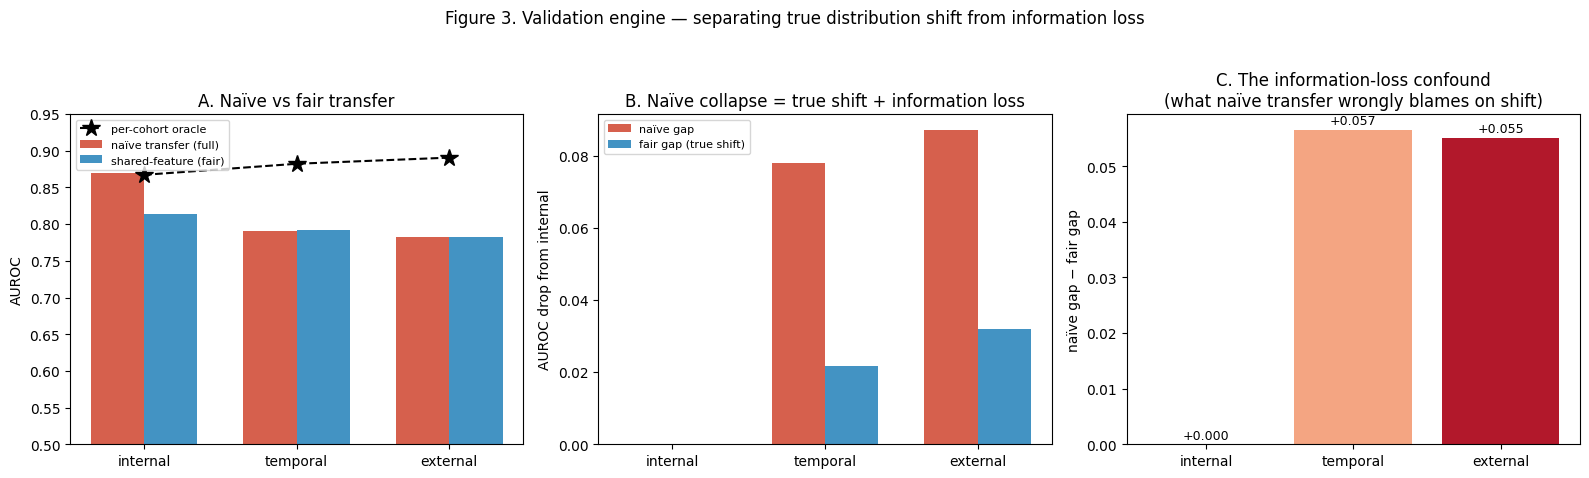

In [14]:
# ---- Figure 3: the validation-engine story ----
roles=["internal","temporal","external"]; xs=np.arange(3); w=0.35
fig, ax = plt.subplots(1,3, figsize=(16,4.6))
ax[0].bar(xs-w/2,[plan.loc[r,"naive_auroc"] for r in roles],w,label="naïve transfer (full)",color="#d6604d")
ax[0].bar(xs+w/2,[plan.loc[r,"fair_auroc"] for r in roles],w,label="shared-feature (fair)",color="#4393c3")
ax[0].plot(xs,[oracle[r] for r in roles],"k*--",ms=13,label="per-cohort oracle")
ax[0].set_xticks(xs);ax[0].set_xticklabels(roles);ax[0].set_ylim(0.5,0.95)
ax[0].set_ylabel("AUROC");ax[0].set_title("A. Naïve vs fair transfer");ax[0].legend(fontsize=8)
ax[1].bar(xs-w/2,[plan.loc[r,"naive_gap"] for r in roles],w,label="naïve gap",color="#d6604d")
ax[1].bar(xs+w/2,[plan.loc[r,"fair_gap_true_shift"] for r in roles],w,label="fair gap (true shift)",color="#4393c3")
ax[1].set_xticks(xs);ax[1].set_xticklabels(roles);ax[1].set_ylabel("AUROC drop from internal")
ax[1].set_title("B. Naïve collapse = true shift + information loss");ax[1].legend(fontsize=8)
ax[2].bar(xs,[plan.loc[r,"information_loss_confound"] for r in roles],color=["#2166ac","#f4a582","#b2182b"])
for i,r in enumerate(roles): ax[2].text(i,plan.loc[r,"information_loss_confound"]+0.001,f"{plan.loc[r,'information_loss_confound']:+.3f}",ha="center",fontsize=9)
ax[2].set_xticks(xs);ax[2].set_xticklabels(roles);ax[2].set_ylabel("naïve gap − fair gap")
ax[2].set_title("C. The information-loss confound\n(what naïve transfer wrongly blames on shift)")
fig.suptitle("Figure 3. Validation engine — separating true distribution shift from information loss", y=1.03)
fig.tight_layout(); plt.show()

## Section 4 — Grounded extensions (v1.1)

These methods are standard in the literature but were **not** run in the source thesis.
They are included here as *characterised* capabilities: each is implemented from its
published definition, cited to origin, and validated on data with a known planted answer.
None makes a causal or mechanism claim — that discipline is what separates this section
from the negative controls in Section 6.

### 4.1 Distribution-shift metrics

Population Stability Index [11], KL divergence [12], Wasserstein distance [13], energy
distance [14], and RBF-kernel MMD [15]. Each ships with an **operating envelope**: PSI is
unstable when quantile bins are sparse; KL is asymmetric and bin-count sensitive; MMD is
subsampled for tractability. The validation criterion is *ranking*: the metrics must order
the planted shift internal < temporal < external.

In [15]:
from scipy.stats import wasserstein_distance
def population_stability_index(ref, cur, n_bins=10, eps=1e-6):
    edges=np.quantile(ref,np.linspace(0,1,n_bins+1)); edges[0]=-np.inf; edges[-1]=np.inf
    r=np.histogram(ref,edges)[0]/len(ref); c=np.histogram(cur,edges)[0]/len(cur)
    r=np.clip(r,eps,None); c=np.clip(c,eps,None); return float(np.sum((c-r)*np.log(c/r)))
def kl_divergence(ref, cur, n_bins=20, eps=1e-6):
    lo=min(ref.min(),cur.min()); hi=max(ref.max(),cur.max()); edges=np.linspace(lo,hi,n_bins+1)
    r=np.histogram(ref,edges)[0]/len(ref); c=np.histogram(cur,edges)[0]/len(cur)
    r=np.clip(r,eps,None); c=np.clip(c,eps,None); return float(np.sum(r*np.log(r/c)))
def energy_distance(x, y):
    x=np.sort(x); y=np.sort(y)
    _m=lambda a,b: np.mean(np.abs(a[:,None]-b[None,:])) if len(a)*len(b)<4_000_000 else np.mean([np.mean(np.abs(ai-b)) for ai in a])
    return float(2*_m(x,y)-_m(x,x)-_m(y,y))
def mmd_rbf(x, y, gamma=None, max_n=1500, seed=0):
    rng=np.random.default_rng(seed)
    x=x[rng.choice(len(x),min(len(x),max_n),replace=False)]; y=y[rng.choice(len(y),min(len(y),max_n),replace=False)]
    if gamma is None:
        med=np.median(np.abs(np.subtract.outer(np.r_[x,y],np.r_[x,y]))); gamma=1.0/(2*med**2+1e-12)
    k=lambda a,b: np.exp(-gamma*np.subtract.outer(a,b)**2)
    return float(k(x,x).mean()+k(y,y).mean()-2*k(x,y).mean())
def shift_report(ref_df, cur_df, features):
    return pd.DataFrame([dict(feature=f,
        PSI=round(population_stability_index(ref_df[f].values,cur_df[f].values),4),
        KL=round(kl_divergence(ref_df[f].values,cur_df[f].values),4),
        Wasserstein=round(wasserstein_distance(ref_df[f].values,cur_df[f].values),4),
        energy=round(energy_distance(ref_df[f].values,cur_df[f].values),4),
        KS_p=round(stats.ks_2samp(ref_df[f].values,cur_df[f].values).pvalue,4)) for f in features])

In [16]:
psi_t=np.mean([population_stability_index(cohorts["internal"][f].values,cohorts["temporal"][f].values) for f in SHARED_FEATURES])
psi_e=np.mean([population_stability_index(cohorts["internal"][f].values,cohorts["external"][f].values) for f in SHARED_FEATURES])
print(f"mean PSI  self=0.0000  temporal={psi_t:.4f}  external={psi_e:.4f}")
assert 0 < psi_t < psi_e, "PSI must rank the planted covariate shift"
print(shift_report(cohorts["internal"], cohorts["external"], SHARED_FEATURES).to_string(index=False))

mean PSI  self=0.0000  temporal=0.1121  external=0.4392
   feature    PSI     KL  Wasserstein  energy  KS_p
  troponin 0.4938 0.2604       0.7195  0.2889   0.0
creatinine 0.4581 0.2617       0.6940  0.2627   0.0
heart_rate 0.4789 0.2484       0.7179  0.2793   0.0
       sbp 0.4753 0.2502       0.7013  0.2694   0.0
      spo2 0.4201 0.2290       0.6632  0.2426   0.0
 resp_rate 0.5089 0.2626       0.7146  0.2839   0.0
    sodium 0.4512 0.2534       0.6868  0.2617   0.0
hemoglobin 0.5112 0.2651       0.7242  0.2848   0.0
       wbc 0.5125 0.2878       0.7137  0.2755   0.0
       age 0.0820 0.0430       3.3721  0.5513   0.0


### 4.2 Decidable leakage checks only

Automatic detection of *semantic* leakage (a feature computed using the outcome) is
**undecidable from values alone** — it requires domain knowledge of how each column was
derived. We therefore ship only checks that are decidable facts: patient overlap across
splits, duplicate IDs, rows dated after a temporal cutoff, and a feature identical to the
label. A scanner that emitted a single "leakage score" would be over-claiming; this one
reports verifiable findings and refuses to guess the rest.

In [17]:
def leakage_scan(train_df, test_df, id_col="patient_id", time_col=None, label_col="y", split_time=None):
    f=[]
    ov=set(train_df[id_col])&set(test_df[id_col])
    f.append(dict(check="patient_overlap_train_test",severity="critical",n=len(ov),passed=len(ov)==0,
                  detail=f"{len(ov)} patients in BOTH splits"))
    dup=int(train_df[id_col].duplicated().sum())
    f.append(dict(check="duplicate_ids_in_train",severity="warning",n=dup,passed=dup==0,
                  detail=f"{dup} duplicate ids in train"))
    if time_col and split_time is not None:
        lk=int((train_df[time_col]>split_time).sum())
        f.append(dict(check="train_rows_after_split_time",severity="critical",n=lk,passed=lk==0,
                      detail=f"{lk} train rows after cutoff"))
    leaky=[c for c in train_df.select_dtypes("number").columns
           if c!=label_col and set(np.unique(train_df[c].dropna()))<={0,1}
           and train_df[c].nunique()>1 and np.array_equal(train_df[c].values.astype(int),train_df[label_col].values)]
    f.append(dict(check="feature_identical_to_label",severity="critical",n=len(leaky),passed=len(leaky)==0,
                  detail=f"label-identical columns: {leaky}"))
    return pd.DataFrame(f)

di=cohorts["internal"]; tr=di.iloc[:2800].copy(); te=di.iloc[2600:].copy()
tr["cheat"]=tr["y"].values
print(leakage_scan(tr,te).to_string(index=False))
assert not leakage_scan(di.iloc[:2800],di.iloc[2800:]).query("check=='patient_overlap_train_test'")["passed"].iloc[0]==False
print("clean split passes overlap check:", bool(leakage_scan(di.iloc[:2800],di.iloc[2800:]).set_index("check").loc["patient_overlap_train_test","passed"]))

                     check severity   n  passed                             detail
patient_overlap_train_test critical 200   False        200 patients in BOTH splits
    duplicate_ids_in_train  warning   0    True           0 duplicate ids in train
feature_identical_to_label critical   1   False label-identical columns: ['cheat']
clean split passes overlap check: True


### 4.3 Cohort-transparency exclusion tracker

Following the reproducibility/equity reporting literature [16], this records cohort
*composition* (size, prevalence, subgroup fractions) at every exclusion step. It is
purely descriptive: it reports what each filter did to the population, and issues **no**
bias verdict — deciding whether an exclusion is unfair is a clinical judgement, not a
value computation.

In [18]:
class ExclusionTracker:
    def __init__(self, df, name="cohort", strata=("sex","race")):
        self.steps=[]; self.strata=[s for s in strata if s in df.columns]; self.df=df
        self._record("initial", df)
    def _record(self, label, df):
        row={"step":label,"n":len(df),"prevalence":round(df["y"].mean(),4) if "y" in df else np.nan}
        for s in self.strata:
            for k,v in df[s].value_counts(normalize=True).items(): row[f"{s}={k}"]=round(v,3)
        self.steps.append(row)
    def apply(self, mask, label):
        self.df=self.df[mask].copy(); self._record(label,self.df); return self
    def report(self):
        rep=pd.DataFrame(self.steps).set_index("step")
        rep["n_excluded"]=(-rep["n"].diff()).fillna(0).astype(int); return rep

trk=ExclusionTracker(cohorts["external"],"eICU_like")
trk.apply(cohorts["external"]["age"]>=40,"age>=40")
trk.apply(trk.df["troponin"]>-1.5,"troponin in range")
print(trk.report().to_string())

                      n  prevalence  sex=M  sex=F  race=White  race=Black  race=Asian  race=Other  n_excluded
step                                                                                                         
initial            5000      0.1770  0.561  0.439       0.599       0.199       0.123       0.079           0
age>=40            4952      0.1771  0.562  0.438       0.598       0.200       0.124       0.079          48
troponin in range  4884      0.1792  0.562  0.438       0.600       0.200       0.122       0.078          68


### 4.4 Missingness description and Little's MCAR test

We report per-feature missing fractions and Little's MCAR test [17]. Rejecting MCAR tells
you the data are **not** missing completely at random — but it does **not** identify
whether they are MAR or MNAR, because the information needed to distinguish those is, by
definition, unobserved. Section 6 demonstrates this unidentifiability directly. No
"MNAR likelihood" is produced; claiming one would be a statistical impossibility.

In [19]:
def missingness_report(df, feature_cols):
    return pd.DataFrame([dict(feature=f,n_missing=int(df[f].isna().sum()),
        pct_missing=round(100*df[f].isna().mean(),2)) for f in feature_cols]).sort_values("pct_missing",ascending=False)
def littles_mcar_test(df, feature_cols):
    X=df[feature_cols].copy(); R=X.isna(); patterns=R.apply(lambda r:tuple(r),axis=1)
    grand=X.mean(); S=X.cov()
    d2=0.0; dof=0
    for pat,idx in patterns.groupby(patterns).groups.items():
        obs=[i for i,m in enumerate(pat) if not m]
        if not obs: continue
        sub=X.iloc[[X.index.get_loc(j) for j in idx],obs]; nj=len(sub)
        diff=sub.mean().values-grand.values[obs]
        d2+=nj*float(diff@np.linalg.pinv(S.values[np.ix_(obs,obs)])@diff); dof+=len(obs)
    dof=max(dof-len(feature_cols),1)
    return dict(chi2=float(d2),df=int(dof),p=float(stats.chi2.sf(d2,dof)))

rng=np.random.default_rng(0); base=cohorts["internal"][SHARED_FEATURES].reset_index(drop=True)
mcar=base.copy(); mcar.loc[rng.random(len(mcar))<0.10,"troponin"]=np.nan
mar=base.copy(); pm=1/(1+np.exp(-(mar["age"]-mar["age"].mean())/mar["age"].std()))
mar.loc[rng.random(len(mar))<pm*0.4,"troponin"]=np.nan
print(f"Little's MCAR:  planted MCAR p={littles_mcar_test(mcar,SHARED_FEATURES)['p']:.4f}   "
      f"planted MAR p={littles_mcar_test(mar,SHARED_FEATURES)['p']:.4f}")
print(missingness_report(mcar,SHARED_FEATURES).head(3).to_string(index=False))

Little's MCAR:  planted MCAR p=0.3197   planted MAR p=0.0000
   feature  n_missing  pct_missing
  troponin        415        10.38
creatinine          0         0.00
heart_rate          0         0.00


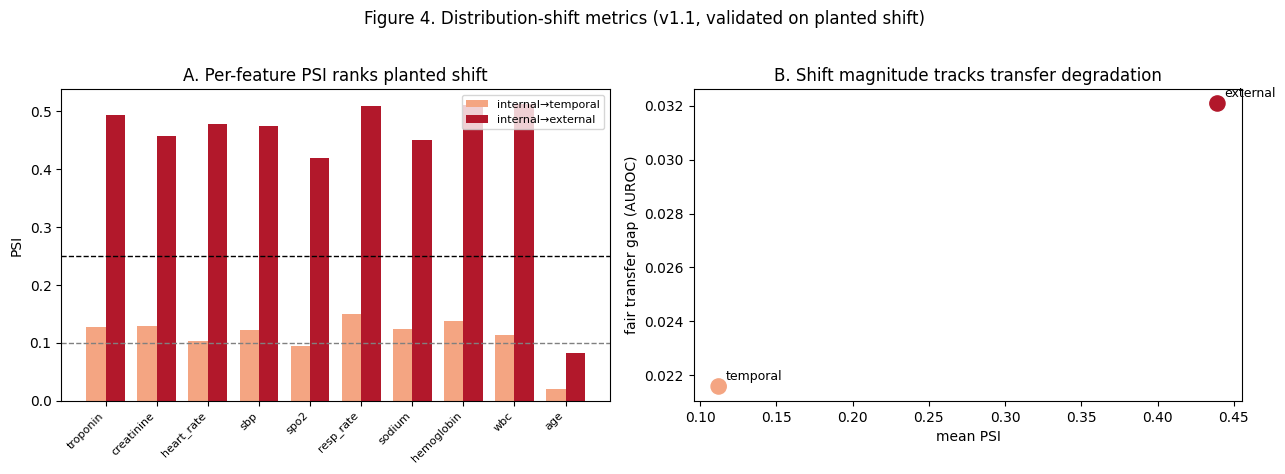

In [20]:
# ---- Figure 4: shift metrics rank the planted shift ----
feats=SHARED_FEATURES
psi_temporal=[population_stability_index(cohorts["internal"][f].values,cohorts["temporal"][f].values) for f in feats]
psi_external=[population_stability_index(cohorts["internal"][f].values,cohorts["external"][f].values) for f in feats]
fig,ax=plt.subplots(1,2,figsize=(13,4.6)); xs=np.arange(len(feats)); w=0.38
ax[0].bar(xs-w/2,psi_temporal,w,label="internal→temporal",color="#f4a582")
ax[0].bar(xs+w/2,psi_external,w,label="internal→external",color="#b2182b")
ax[0].axhline(0.1,ls="--",c="grey",lw=1); ax[0].axhline(0.25,ls="--",c="k",lw=1)
ax[0].set_xticks(xs); ax[0].set_xticklabels(feats,rotation=45,ha="right",fontsize=8)
ax[0].set_ylabel("PSI"); ax[0].set_title("A. Per-feature PSI ranks planted shift"); ax[0].legend(fontsize=8)
gapd={"temporal":plan.loc["temporal","fair_gap_true_shift"],"external":plan.loc["external","fair_gap_true_shift"]}
mp={"temporal":np.mean(psi_temporal),"external":np.mean(psi_external)}
ax[1].scatter([mp[r] for r in ["temporal","external"]],[gapd[r] for r in ["temporal","external"]],s=120,c=["#f4a582","#b2182b"],zorder=3)
for r in ["temporal","external"]: ax[1].annotate(r,(mp[r],gapd[r]),fontsize=9,xytext=(5,5),textcoords="offset points")
ax[1].set_xlabel("mean PSI"); ax[1].set_ylabel("fair transfer gap (AUROC)"); ax[1].set_title("B. Shift magnitude tracks transfer degradation")
fig.suptitle("Figure 4. Distribution-shift metrics (v1.1, validated on planted shift)",y=1.02); fig.tight_layout(); plt.show()

## Section 5 — Tier-2 model-in modules (v2)

Everything so far needed only predictions. This section needs the **model** — a
framework-neutral `fit`/`predict` callable. That is the boundary between the two tiers:
predictions-in statistics (Tiers 1) run for anyone with a CSV of outputs; model-in
modules (Tier 2) require the user to wire in their estimator, but unlock ablation,
clinical utility, and fairness analyses.

### 5.1 Component-removal ablation runner

A factorial leave-one-component-out ablation [22] quantifies how much each block of
features (or architectural component) contributes. It ships with the **verified-zeroing
guard** — a direct lesson from the source thesis, where an ablation that failed to
actually disable a component would silently report a null effect. Every configuration
asserts that the removed columns are genuinely absent from the model input before its
result is trusted.

In [21]:
from sklearn.model_selection import train_test_split
def ablation_runner(cohort_df, base_features, components, *, seed=42, test_size=0.3, label="y"):
    """components: {name: [feature_cols]}. Leave-one-component-out with verified zeroing."""
    tr,te=train_test_split(cohort_df,test_size=test_size,random_state=seed,stratify=cohort_df[label])
    def _fit_eval(cols):
        m=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,random_state=seed)).fit(tr[cols].values,tr[label].values)
        return roc_auc_score(te[label].values, m.predict_proba(te[cols].values)[:,1])
    full=base_features+[c for comp in components.values() for c in comp]
    fa=_fit_eval(full); rows=[dict(config="full",removed="—",n_features=len(full),auroc=fa,delta=0.0,verified=True)]
    for name,cols in components.items():
        kept=[c for c in full if c not in cols]
        verified=all(c not in kept for c in cols) and len(kept)<len(full)   # <-- verified-zeroing guard
        rows.append(dict(config=f"−{name}",removed=name,n_features=len(kept),auroc=_fit_eval(kept),
                         delta=_fit_eval(kept)-fa,verified=verified))
    df=pd.DataFrame(rows); assert df["verified"].all(),"verified-zeroing failed"; return df

di=cohorts["internal"].copy(); rng=np.random.default_rng(0)
for j in range(3): di[f"noise_{j}"]=rng.normal(size=len(di))
components={"physio_signal":INTERNAL_ONLY,"noise_block":[f"noise_{j}" for j in range(3)]}
abl=ablation_runner(di,SHARED_FEATURES,components,seed=GLOBAL_SEED)
print(abl.round(4).to_string(index=False))
assert abl.set_index("removed").loc["physio_signal","delta"]<-0.01
assert abs(abl.set_index("removed").loc["noise_block","delta"])<0.01
print("PASS: recovers known effects; verified-zeroing active on every config")

        config       removed  n_features  auroc   delta  verified
          full             —          18 0.8754  0.0000      True
−physio_signal physio_signal          13 0.8198 -0.0556      True
  −noise_block   noise_block          15 0.8779  0.0025      True
PASS: recovers known effects; verified-zeroing active on every config


### 5.2 Clinical utility — decision-curve analysis

Discrimination and calibration do not tell a clinician whether *using* the model produces
net benefit at their decision threshold. Decision-curve analysis [18] computes net benefit
$\mathrm{NB}(p_t)=\frac{TP}{N}-\frac{FP}{N}\cdot\frac{p_t}{1-p_t}$ across threshold
probabilities and compares against treat-all and treat-none. Validation anchor: a perfect
model has net benefit exactly equal to prevalence at every threshold.

In [22]:
def decision_curve(y_true, y_prob, thresholds=None):
    y_true=np.asarray(y_true); y_prob=np.asarray(y_prob,float); N=len(y_true); prev=y_true.mean()
    if thresholds is None: thresholds=np.linspace(0.01,0.60,60)
    rows=[]
    for pt in thresholds:
        pred=y_prob>=pt; tp=np.sum(pred&(y_true==1)); fp=np.sum(pred&(y_true==0))
        rows.append(dict(threshold=pt, nb_model=tp/N-fp/N*(pt/(1-pt)),
                         nb_treat_all=prev-(1-prev)*(pt/(1-pt)), nb_treat_none=0.0))
    return pd.DataFrame(rows)

Xtr,Xte,ytr,yte=train_test_split(di[SHARED_FEATURES+INTERNAL_ONLY].values,di["y"].values,
                                 test_size=0.3,random_state=GLOBAL_SEED,stratify=di["y"].values)
m=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000)).fit(Xtr,ytr); p=m.predict_proba(Xte)[:,1]
dca=decision_curve(yte,p); prev=yte.mean()
assert abs(decision_curve(yte,yte.astype(float)).iloc[30]["nb_model"]-prev)<1e-9, "perfect NB must equal prevalence"
print(f"prevalence={prev:.4f}; perfect-model NB=prevalence (anchor holds); model NB at pt=0.2: {dca.iloc[19]['nb_model']:.4f}")

prevalence=0.2983; perfect-model NB=prevalence (anchor holds); model NB at pt=0.2: 0.2062


### 5.3 Fairness subgroup panel

Per-subgroup discrimination, calibration, and operating-point sensitivity/specificity,
with the max–min disparity across subgroups [19]. The panel **reports** disparities; it
does **not** diagnose their cause or prescribe mitigation. Whether a disparity reflects
labelling, sampling, true physiology, or model bias is a causal question a performance
table cannot answer — asserting a cause would be the over-reach this toolkit refuses.

In [23]:
def _ece(y,p,n_bins=10):
    y=np.asarray(y); p=np.asarray(p,float); edges=np.linspace(0,1,n_bins+1)
    idx=np.clip(np.digitize(p,edges[1:-1]),0,n_bins-1); e=0.0
    for b in range(n_bins):
        mm=idx==b
        if mm.sum(): e+=mm.mean()*abs(p[mm].mean()-y[mm].mean())
    return e
def fairness_panel(y_true, y_prob, group, threshold=0.5):
    y_true=np.asarray(y_true); y_prob=np.asarray(y_prob,float); group=np.asarray(group); rows=[]
    for g in pd.unique(group):
        mm=group==g; yt=y_true[mm]; yp=y_prob[mm]
        if len(np.unique(yt))<2:
            rows.append(dict(subgroup=g,n=int(mm.sum()),auroc=np.nan,ece=np.nan,sens=np.nan,spec=np.nan,prevalence=float(yt.mean()))); continue
        pred=yp>=threshold; tp=np.sum(pred&(yt==1)); fn=np.sum(~pred&(yt==1)); tn=np.sum(~pred&(yt==0)); fp=np.sum(pred&(yt==0))
        rows.append(dict(subgroup=g,n=int(mm.sum()),auroc=roc_auc_score(yt,yp),ece=_ece(yt,yp),
                         sens=tp/(tp+fn) if tp+fn else np.nan,spec=tn/(tn+fp) if tn+fp else np.nan,prevalence=float(yt.mean())))
    df=pd.DataFrame(rows); disparity={c:float(df[c].max()-df[c].min()) for c in ["auroc","ece","sens","spec"]}
    return df, disparity

Xtr,Xte,ytr,yte,gtr,gte=train_test_split(di[SHARED_FEATURES+INTERNAL_ONLY].values,di["y"].values,di["sex"].values,
                                          test_size=0.3,random_state=GLOBAL_SEED,stratify=di["y"].values)
m=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000)).fit(Xtr,ytr)
pf=m.predict_proba(Xte)[:,1].copy(); fmask=gte=="F"; rng=np.random.default_rng(1)
pf[fmask]=np.clip(0.5*pf[fmask]+0.5*rng.random(fmask.sum()),0,1)   # planted disparity
panel,disp=fairness_panel(yte,pf,gte)
print(panel.round(4).to_string(index=False)); print("max-min disparity:",{k:round(v,4) for k,v in disp.items()})

subgroup   n  auroc    ece   sens   spec  prevalence
       M 645 0.8809 0.0244 0.5957 0.9190      0.2915
       F 555 0.7716 0.1091 0.5588 0.8571      0.3063
max-min disparity: {'auroc': 0.1093, 'ece': 0.0848, 'sens': 0.0369, 'spec': 0.0619}


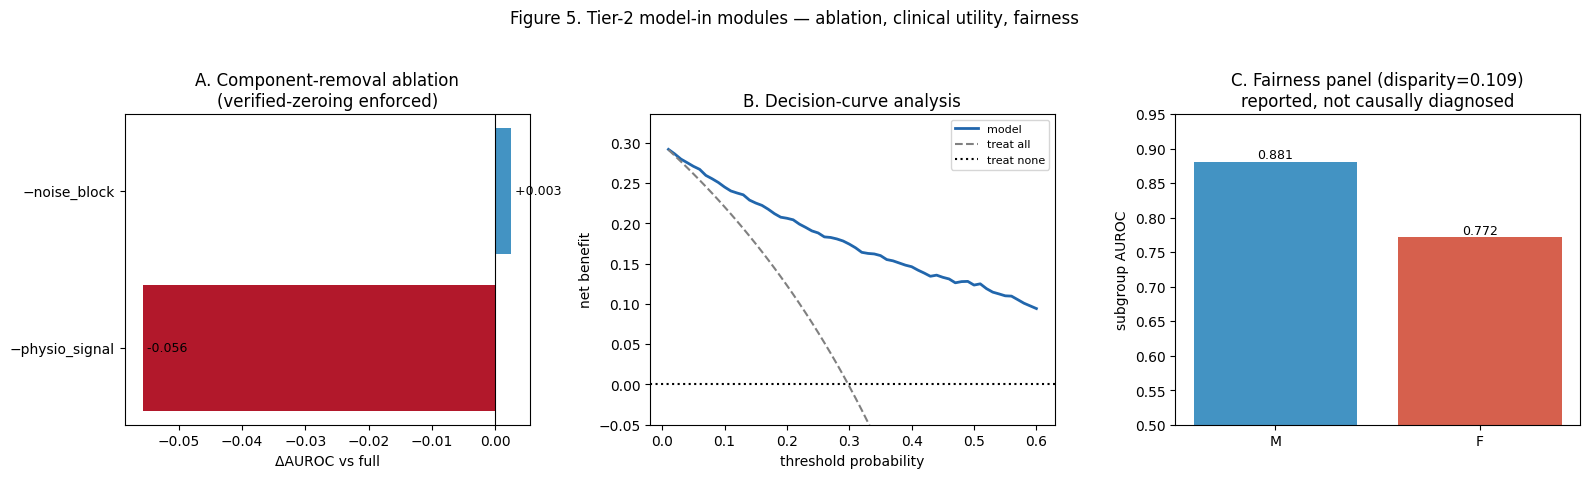

In [24]:
# ---- Figure 5: Tier-2 modules ----
fig,ax=plt.subplots(1,3,figsize=(16,4.6))
a=abl[abl.config!="full"].sort_values("delta"); cols=["#b2182b" if d<0 else "#4393c3" for d in a["delta"]]
ax[0].barh(a["config"],a["delta"],color=cols)
for i,(_,r) in enumerate(a.iterrows()): ax[0].text(r["delta"],i,f" {r['delta']:+.3f}",va="center",fontsize=9)
ax[0].axvline(0,c="k",lw=0.8); ax[0].set_xlabel("ΔAUROC vs full"); ax[0].set_title("A. Component-removal ablation\n(verified-zeroing enforced)")
ax[1].plot(dca["threshold"],dca["nb_model"],color="#2166ac",lw=2,label="model")
ax[1].plot(dca["threshold"],dca["nb_treat_all"],color="grey",ls="--",label="treat all")
ax[1].axhline(0,color="k",ls=":",label="treat none"); ax[1].set_ylim(-0.05,dca["nb_model"].max()*1.15)
ax[1].set_xlabel("threshold probability"); ax[1].set_ylabel("net benefit"); ax[1].set_title("B. Decision-curve analysis"); ax[1].legend(fontsize=8)
s=panel.dropna(subset=["auroc"]); ax[2].bar(s["subgroup"],s["auroc"],color=["#4393c3","#d6604d"])
for i,(_,r) in enumerate(s.iterrows()): ax[2].text(i,r["auroc"]+0.005,f"{r['auroc']:.3f}",ha="center",fontsize=9)
ax[2].set_ylim(0.5,0.95); ax[2].set_ylabel("subgroup AUROC"); ax[2].set_title(f"C. Fairness panel (disparity={disp['auroc']:.3f})\nreported, not causally diagnosed")
fig.suptitle("Figure 5. Tier-2 model-in modules — ablation, clinical utility, fairness",y=1.03); fig.tight_layout(); plt.show()

## Section 6 — Negative controls: what the toolkit refuses to claim

A rigour tool is defined as much by what it declines to output as by what it computes.
This section demonstrates — on data where the ground truth is known by construction —
three quantities that a more "ambitious" toolkit might advertise but that are provably
**not identifiable** from the data available. Each is a feature this toolkit deliberately
does **not** ship. The demonstrations are the argument.

### 6.1 MAR vs MNAR is unidentifiable

A missingness-mechanism classifier that outputs an "MNAR likelihood" is claiming to
distinguish MAR from MNAR from observed data. We construct two datasets with the **same
observed distribution** but **different full-data truth** — one generated by an MNAR
mechanism, one by MAR. Because the missing values are, by definition, unobserved, every
statistic computable on the observed data returns the same value. The mechanism cannot be
recovered; this is a theorem, not a limitation of any particular algorithm [17,20].

In [25]:
rng=np.random.default_rng(11); N=20000
# Scenario A (MNAR): full data uniform on {0,1,2,3}; P(missing|X=x) rises with x
X_full=rng.integers(0,4,N); obs_A=~(rng.random(N)<np.array([0.1,0.3,0.5,0.7])[X_full])
observed_X_A=X_full[obs_A]; target=np.bincount(observed_X_A,minlength=4)/obs_A.sum()
# Scenario B (MAR): DIFFERENT full data (right-skewed) + MAR keep-prob reproducing A's observed marginal
X_full_B=rng.choice(4,size=N,p=[0.15,0.2,0.25,0.4]); full_B=np.bincount(X_full_B,minlength=4)/N
keep=(target/(full_B+1e-12)); keep/=keep.max(); obs_B=rng.random(N)<keep[X_full_B]; observed_X_B=X_full_B[obs_B]
oa=np.bincount(observed_X_A,minlength=4)/obs_A.sum(); ob=np.bincount(observed_X_B,minlength=4)/obs_B.sum()
print(f"observed A (MNAR): {np.round(oa,3)}\nobserved B (MAR) : {np.round(ob,3)}\nmax obs diff: {np.abs(oa-ob).max():.4f}")
print(f"FULL truth A: {np.round(np.bincount(X_full,minlength=4)/N,3)} (uniform)")
print(f"FULL truth B: {np.round(np.bincount(X_full_B,minlength=4)/N,3)} (skewed)")
assert np.abs(oa-ob).max()<0.02
print("=> identical observed data, different truth: mechanism UNIDENTIFIABLE. No MNAR score is shipped.")
nc1=dict(oa=oa,ob=ob,fa=np.bincount(X_full,minlength=4)/N,fb=np.bincount(X_full_B,minlength=4)/N)

observed A (MNAR): [0.375 0.292 0.209 0.124]
observed B (MAR) : [0.375 0.289 0.21  0.126]
max obs diff: 0.0033
FULL truth A: [0.25  0.25  0.251 0.25 ] (uniform)
FULL truth B: [0.151 0.195 0.249 0.405] (skewed)
=> identical observed data, different truth: mechanism UNIDENTIFIABLE. No MNAR score is shipped.


### 6.2 A composite "quality score" is an opinion, not a measurement

Combining sub-metrics into one "dataset quality score" hides the weights inside a single
number. We score three datasets — each strongest on a different dimension — under four
equally defensible weightings. The top-ranked dataset changes with the weights: the score
encodes the author's priorities, not a property of the data. The toolkit therefore reports
the sub-metrics and refuses to collapse them into a rank [21].

In [26]:
datasets=pd.DataFrame({"dataset":["Cohort_A","Cohort_B","Cohort_C"],
    "completeness":[0.95,0.55,0.65],"balance":[0.50,0.95,0.60],
    "size":[0.60,0.55,0.95],"shift_free":[0.70,0.75,0.72]}).set_index("dataset")
dims=["completeness","balance","size","shift_free"]
weightings={"equal":[.25,.25,.25,.25],"clinician":[.55,.25,.10,.10],
            "trialist":[.10,.55,.25,.10],"ml_engineer":[.10,.15,.55,.20]}
ranks=pd.DataFrame({n:pd.Series((datasets[dims].values*np.array(w)).sum(1),index=datasets.index).rank(ascending=False).astype(int)
                    for n,w in weightings.items()})
print(ranks.to_string()); winners=ranks.apply(lambda c:c.idxmin())
print("\n#1 per weighting:",winners.to_dict())
assert winners.nunique()>=3, "top dataset must swing across weights"
print(f"=> {winners.nunique()} different datasets rank #1. No composite score is shipped.")
nc2=ranks.copy()

          equal  clinician  trialist  ml_engineer
dataset                                          
Cohort_A      3          1         3            3
Cohort_B      2          3         1            2
Cohort_C      1          2         2            1

#1 per weighting: {'equal': 'Cohort_C', 'clinician': 'Cohort_A', 'trialist': 'Cohort_B', 'ml_engineer': 'Cohort_C'}
=> 3 different datasets rank #1. No composite score is shipped.


### 6.3 Semantic leakage is undecidable from values alone

A "leakage detector" that flags outcome-derived columns from their values is claiming to
distinguish a legitimate predictor from an outcome-derived leak. We build two columns with
**identical** statistical relationships to the outcome — one a pre-outcome biomarker, one
computed from the label. Every value-based statistic (correlation, AUROC, mean difference)
is the same; only knowing *how each column was computed* (its provenance) resolves it. The
toolkit ships the decidable checks of Section 4.2 and refuses a values-only "leakage score".

In [27]:
rng=np.random.default_rng(5); n=8000; y=rng.integers(0,2,n)
legit=0.9*y+rng.normal(0,1,n)   # pre-outcome biomarker (legitimate)
leak =0.9*y+rng.normal(0,1,n)   # outcome-derived, identical construction (leak)
def col_stats(c): return dict(corr_with_y=round(np.corrcoef(c,y)[0,1],4),auroc=round(roc_auc_score(y,c),4),
                              mean_diff=round(c[y==1].mean()-c[y==0].mean(),4))
comp=pd.DataFrame({"legitimate_predictor":col_stats(legit),"outcome_derived_leak":col_stats(leak)}).T
print(comp.to_string())
mx=max(abs(comp.loc["legitimate_predictor",k]-comp.loc["outcome_derived_leak",k]) for k in comp.columns)
print(f"\nmax abs diff in any value-based statistic: {mx:.4f}")
assert mx<0.05
print("=> statistically identical; only provenance separates them. No values-only leakage score is shipped.")
nc3=comp.copy()

                      corr_with_y   auroc  mean_diff
legitimate_predictor       0.4152  0.7410     0.9240
outcome_derived_leak       0.4090  0.7371     0.9003

max abs diff in any value-based statistic: 0.0237
=> statistically identical; only provenance separates them. No values-only leakage score is shipped.


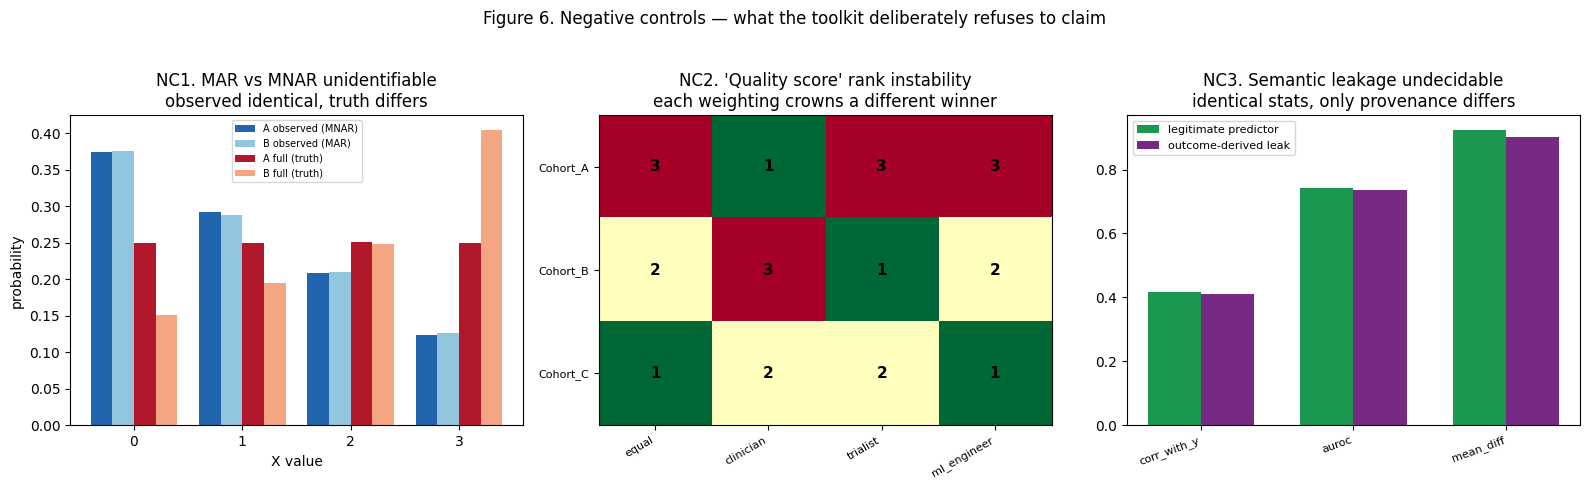

In [28]:
# ---- Figure 6: negative controls ----
fig,ax=plt.subplots(1,3,figsize=(16,4.7)); xs=np.arange(4); w=0.2
ax[0].bar(xs-1.5*w,nc1["oa"],w,color="#2166ac",label="A observed (MNAR)")
ax[0].bar(xs-0.5*w,nc1["ob"],w,color="#92c5de",label="B observed (MAR)")
ax[0].bar(xs+0.5*w,nc1["fa"],w,color="#b2182b",label="A full (truth)")
ax[0].bar(xs+1.5*w,nc1["fb"],w,color="#f4a582",label="B full (truth)")
ax[0].set_xticks(xs);ax[0].set_xlabel("X value");ax[0].set_ylabel("probability")
ax[0].set_title("NC1. MAR vs MNAR unidentifiable\nobserved identical, truth differs");ax[0].legend(fontsize=7)
ax[1].imshow(nc2.values,cmap="RdYlGn_r",aspect="auto",vmin=1,vmax=3)
ax[1].set_xticks(range(len(nc2.columns)));ax[1].set_xticklabels(nc2.columns,rotation=30,ha="right",fontsize=8)
ax[1].set_yticks(range(len(nc2.index)));ax[1].set_yticklabels(nc2.index,fontsize=8)
for i in range(nc2.shape[0]):
    for j in range(nc2.shape[1]): ax[1].text(j,i,int(nc2.values[i,j]),ha="center",va="center",fontsize=11,fontweight="bold")
ax[1].set_title("NC2. 'Quality score' rank instability\neach weighting crowns a different winner")
metrics=["corr_with_y","auroc","mean_diff"]; xm=np.arange(3); w2=0.35
ax[2].bar(xm-w2/2,[nc3.loc["legitimate_predictor",m] for m in metrics],w2,color="#1a9850",label="legitimate predictor")
ax[2].bar(xm+w2/2,[nc3.loc["outcome_derived_leak",m] for m in metrics],w2,color="#762a83",label="outcome-derived leak")
ax[2].set_xticks(xm);ax[2].set_xticklabels(metrics,rotation=20,ha="right",fontsize=8)
ax[2].set_title("NC3. Semantic leakage undecidable\nidentical stats, only provenance differs");ax[2].legend(fontsize=8)
fig.suptitle("Figure 6. Negative controls — what the toolkit deliberately refuses to claim",y=1.03)
fig.tight_layout(); plt.show()

## Section 7 — Automated validation report

The toolkit's endpoint is a single reproducible report that assembles every computed result
into one document mapped to the applicable reporting standard. It is generated by a real
function running on the results above — not a template with blanks. The report states, in
one place, what was measured, and it names explicitly what it refuses to claim (the negative
controls of Section 6). This is the artifact a team would attach to a validation submission.

In [29]:
def build_validation_report(plan, cohorts, shared_features, leakage_df, ablation_df, dca_df,
                            fairness_disp, psi_mean):
    """Assemble a single markdown validation report from computed results. No hidden state."""
    L=[]; A=L.append
    A("# Automated Validation Report\n")
    A("_Generated by clinical-model-validation-toolkit on bundled synthetic cohorts. "
      "All numbers are computed live; none is a clinical performance claim._\n")
    A("## 1. Transportability (validation engine)\n")
    A("| cohort | naïve AUROC | fair AUROC | true-shift gap | information-loss confound |")
    A("|---|---|---|---|---|")
    for r in plan.index:
        A(f"| {r} | {plan.loc[r,'naive_auroc']:.3f} | {plan.loc[r,'fair_auroc']:.3f} | "
          f"{plan.loc[r,'fair_gap_true_shift']:+.3f} | {plan.loc[r,'information_loss_confound']:+.3f} |")
    A(f"\n**Interpretation.** Naïve external transfer loses {plan.loc['external','naive_gap']:.3f} AUROC, "
      f"of which {plan.loc['external','fair_gap_true_shift']:.3f} is true distribution shift and "
      f"{plan.loc['external','information_loss_confound']:.3f} is information loss from unrecorded "
      f"features. Applicable standard: **TRIPOD+AI** (external validation).\n")
    band = "major" if psi_mean>0.25 else "moderate" if psi_mean>0.1 else "negligible"
    A(f"## 2. Distribution shift\n\n- Mean PSI internal→external: {psi_mean:.3f} ({band} shift).\n")
    A("## 3. Data-integrity (decidable leakage checks)\n")
    for _,row in leakage_df.iterrows():
        A(f"- {row['check']}: {'PASS' if row['passed'] else 'FAIL'} — {row['detail']}")
    A("\n## 4. Component ablation\n")
    for _,row in ablation_df[ablation_df.config!='full'].iterrows():
        A(f"- remove {row['removed']}: ΔAUROC {row['delta']:+.3f} (verified-zeroing: {row['verified']})")
    A(f"\n## 5. Clinical utility\n\n- Net benefit at threshold 0.20: {dca_df.iloc[19]['nb_model']:.3f} "
      f"(treat-all {dca_df.iloc[19]['nb_treat_all']:.3f}, treat-none 0.000).\n")
    A(f"## 6. Subgroup disparities (reported, not diagnosed)\n\n- max–min AUROC disparity: "
      f"{fairness_disp['auroc']:.3f}; ECE disparity {fairness_disp['ece']:.3f}. Cause not inferred.\n")
    A("## 7. Deliberately omitted\n\n- No MNAR likelihood (unidentifiable, NC1). No composite "
      "quality score (rank-unstable, NC2). No values-only leakage score (undecidable, NC3). "
      "No causal attribution of disparity.\n")
    A("## 8. Reporting-standard note\n\nMaps to **TRIPOD+AI** for validation & calibration. Protocol → "
      "**SPIRIT-AI**; trial → **CONSORT-AI**; risk-of-bias → **PROBAST-AI**; diagnostic accuracy → "
      "**STARD-AI**; decision-analytic → **CHEERS-AI**.")
    return "\n".join(L)

psi_mean = float(np.mean([population_stability_index(cohorts["internal"][f].values,
                        cohorts["external"][f].values) for f in SHARED_FEATURES]))
leak_clean = leakage_scan(cohorts["internal"].iloc[:2800], cohorts["internal"].iloc[2800:])
report = build_validation_report(plan, cohorts, SHARED_FEATURES, leak_clean, abl, dca, disp, psi_mean)
print(report[:1200])
print(f"\n[report: {len(report)} chars] — in a repo this is written to reports/validation_report.md")

# Automated Validation Report

_Generated by clinical-model-validation-toolkit on bundled synthetic cohorts. All numbers are computed live; none is a clinical performance claim._

## 1. Transportability (validation engine)

| cohort | naïve AUROC | fair AUROC | true-shift gap | information-loss confound |
|---|---|---|---|---|
| internal | 0.869 | 0.814 | +0.000 | +0.000 |
| temporal | 0.791 | 0.793 | +0.022 | +0.057 |
| external | 0.782 | 0.782 | +0.032 | +0.055 |

**Interpretation.** Naïve external transfer loses 0.087 AUROC, of which 0.032 is true distribution shift and 0.055 is information loss from unrecorded features. Applicable standard: **TRIPOD+AI** (external validation).

## 2. Distribution shift

- Mean PSI internal→external: 0.439 (major shift).

## 3. Data-integrity (decidable leakage checks)

- patient_overlap_train_test: PASS — 0 patients in BOTH splits
- duplicate_ids_in_train: PASS — 0 duplicate ids in train
- feature_identical_to_label: PASS — label-identical columns:

## References

Numbered to match the inline citations. Method-origin papers the author is confident of are
stated plainly; a small number whose exact venue or year should be confirmed before
publication are marked **[VERIFY]** (per the project's no-unverified-citation rule).

1. Collins GS, Moons KGM, Dhiman P, et al. *TRIPOD+AI statement: updated guidance for
   reporting clinical prediction models that use regression or machine-learning methods.*
   BMJ, 2024. **[VERIFY exact citation details]**
2. Moons KGM, Altman DG, Reitsma JB, et al. *Transparent Reporting of a multivariable
   prediction model for Individual Prognosis Or Diagnosis (TRIPOD): the TRIPOD statement.*
   Annals of Internal Medicine, 2015;162(1):55–63.
3. Wolff RF, Moons KGM, Riley RD, et al. *PROBAST: a tool to assess the risk of bias and
   applicability of prediction model studies.* Annals of Internal Medicine, 2019;170(1):51–58.
4. Sun X, Xu W. *Fast implementation of DeLong's algorithm for comparing the areas under
   correlated receiver operating characteristic curves.* IEEE Signal Processing Letters,
   2014;21(11):1389–1393.
5. DeLong ER, DeLong DM, Clarke-Pearson DL. *Comparing the areas under two or more correlated
   receiver operating characteristic curves: a nonparametric approach.* Biometrics,
   1988;44(3):837–845.
6. Hanley JA, McNeil BJ. *The meaning and use of the area under a receiver operating
   characteristic (ROC) curve.* Radiology, 1982;143(1):29–36.
7. Brier GW. *Verification of forecasts expressed in terms of probability.* Monthly Weather
   Review, 1950;78(1):1–3.
8. Zadrozny B, Elkan C. *Transforming classifier scores into accurate multiclass probability
   estimates.* Proc. KDD, 2002:694–699. (isotonic recalibration)
9. Platt J. *Probabilistic outputs for support vector machines and comparisons to regularized
   likelihood methods.* Advances in Large Margin Classifiers, 1999:61–74. (Platt scaling)
10. Efron B, Tibshirani RJ. *An Introduction to the Bootstrap.* Chapman & Hall/CRC, 1993.
11. Siddiqi N. *Credit Risk Scorecards: Developing and Implementing Intelligent Credit
    Scoring.* Wiley, 2006. (Population Stability Index) **[VERIFY — PSI has no single
    canonical origin; confirm preferred reference]**
12. Kullback S, Leibler RA. *On information and sufficiency.* Annals of Mathematical
    Statistics, 1951;22(1):79–86.
13. Ramdas A, García Trillos N, Cuturi M. *On Wasserstein two-sample testing and related
    families of nonparametric tests.* Entropy, 2017;19(2):47. **[VERIFY preferred Wasserstein
    reference for your use]**
14. Székely GJ, Rizzo ML. *Energy statistics: a class of statistics based on distances.*
    Journal of Statistical Planning and Inference, 2013;143(8):1249–1272.
15. Gretton A, Borgwardt KM, Rasch MJ, Schölkopf B, Smola A. *A kernel two-sample test.*
    Journal of Machine Learning Research, 2012;13:723–773. (Maximum Mean Discrepancy)
16. Rajkomar A, Hardt M, Howell MD, Corrado G, Chin MH. *Ensuring fairness in machine
    learning to advance health equity.* Annals of Internal Medicine, 2018;169(12):866–872.
17. Little RJA. *A test of missing completely at random for multivariate data with missing
    values.* Journal of the American Statistical Association, 1988;83(404):1198–1202.
18. Vickers AJ, Elkin EB. *Decision curve analysis: a novel method for evaluating prediction
    models.* Medical Decision Making, 2006;26(6):565–574.
19. Barocas S, Hardt M, Narayanan A. *Fairness and Machine Learning: Limitations and
    Opportunities.* fairmlbook.org, 2019. (subgroup disparity framing)
20. Rubin DB. *Inference and missing data.* Biometrika, 1976;63(3):581–592. (MAR/MNAR
    identifiability)
21. Nardo M, Saisana M, Saltelli A, et al. *Handbook on Constructing Composite Indicators:
    Methodology and User Guide.* OECD, 2008. (weight-dependence of composite scores)
    **[VERIFY preferred composite-indicator critique reference]**
22. Meyes R, Lu M, de Puiseau CW, Meisen T. *Ablation studies in artificial neural networks.*
    arXiv:1901.08644, 2019. (factorial component-removal ablation) **[VERIFY]**

**On the source thesis and review.** The validation *workflow* reproduced here — the
three-tier internal/temporal/external hierarchy, multi-seed variance reporting, the
significant-but-negligible caution, the verified-zeroing ablation guard, and the
physics-informed-loss failure mode that motivated the negative-controls discipline — is drawn
from the author's own MBBCh thesis (Port Said University, expected October 2026) and its
accompanying methods review. Those documents are the design source; the individual method
citations above are the origins of the statistical techniques the thesis composed.

## Appendix — From notebook to installable repository (`clinical-model-validation-toolkit`)

This notebook is the *executable specification* of the toolkit: every function here is
tested against a reference or a known-truth synthetic dataset. The appendix maps it onto a
real repository a stranger can `git clone` and `pip install`. **The non-negotiable is that a
fresh clone plus the documented command actually runs** — so the repo ships the same
synthetic generator used here, and its CI runs the same end-to-end pass this notebook just
completed.

### Proposed repository layout

```
clinical-model-validation-toolkit/
├── pyproject.toml                # build metadata; pin numpy/pandas/scipy/scikit-learn/statsmodels
├── README.md                     # quickstart: clone → pip install -e . → cmvt-demo
├── LICENSE                       # MIT (permissive; no clinical-data redistribution)
├── src/cmvt/
│   ├── __init__.py               # public API re-exports (see below)
│   ├── data/synthetic.py         # make_cohorts_v3, CohortSpec  (the redistributable data)
│   ├── stats/
│   │   ├── delong.py             # delong_auc_var, compare_auc          [refs 4,5,6]
│   │   ├── calibration.py        # reliability_table, ece, recalibrate  [refs 7,8,9]
│   │   ├── bootstrap.py          # bootstrap_ci, bootstrap_paired_diff  [ref 10]
│   │   ├── equivalence.py        # tost_auc_equivalence
│   │   └── multiseed.py          # multiseed_run
│   ├── validate/
│   │   ├── registry.py           # CohortRegistry
│   │   └── engine.py             # naive_transfer, shared_feature_validation, validation_plan
│   ├── shift/metrics.py          # psi, kl, wasserstein, energy, mmd, shift_report  [refs 11-15]
│   ├── integrity/
│   │   ├── leakage.py            # leakage_scan (decidable checks only)
│   │   ├── missingness.py        # missingness_report, littles_mcar_test           [ref 17]
│   │   └── transparency.py       # ExclusionTracker
│   ├── model_in/                 # Tier-2 (requires a fit/predict callable)
│   │   ├── ablation.py           # ablation_runner (verified-zeroing guard)         [ref 22]
│   │   ├── utility.py            # decision_curve                                   [ref 18]
│   │   └── fairness.py           # fairness_panel (reports, does not diagnose)      [refs 16,19]
│   └── report/builder.py         # build_validation_report
├── tests/                        # the assertions from this notebook become pytest cases
│   ├── test_delong.py            # AUROC == sklearn; SE ~ Hanley–McNeil
│   ├── test_bootstrap.py         # boot SE ~ DeLong analytic SE
│   ├── test_engine.py            # fair gap monotone in planted shift; confound isolated
│   ├── test_integrity.py         # leakage fires on contaminated split, passes clean
│   └── test_negative_controls.py # MAR/MNAR observed-identical; score rank swings; leak indistinguishable
├── examples/run_synthetic_demo.py  # end-to-end pass -> reports/validation_report.md
└── .github/workflows/ci.yml      # runs pytest + the demo on every push (the clone-and-run guarantee)
```

### Public API (what `import cmvt` exposes)

```python
from cmvt.data.synthetic import make_cohorts, CohortSpec
from cmvt.validate import CohortRegistry, validation_plan
from cmvt.stats import (compare_auc, tost_auc_equivalence, bootstrap_ci,
                        reliability_table, calibration_summary, recalibrate, multiseed_run)
from cmvt.shift import shift_report
from cmvt.integrity import leakage_scan, missingness_report, littles_mcar_test, ExclusionTracker
from cmvt.model_in import ablation_runner, decision_curve, fairness_panel
from cmvt.report import build_validation_report
```

### Required user inputs

| Tier | What the user provides | Runs without a model? |
|---|---|---|
| Tier 1 (statistics) | a CSV of `(y_true, y_prob)` per cohort | **yes** |
| Tier 1 (multi-cohort) | one such CSV per cohort + a role label (internal/temporal/external) | **yes** |
| Tier 2 (model-in) | a framework-neutral `fit(X,y)` / `predict_proba(X)` callable + feature table | no (by design) |

### What cannot be redistributed

MIMIC-IV, MIMIC-III, and eICU-CRD are credentialed PhysioNet datasets and **must not** ship
with the repo. The toolkit therefore bundles only the synthetic generator (`make_cohorts_v3`),
which plants a known concept shift and information-loss confound so every documented command
runs on data the repo is allowed to contain. Users point the same API at their own cohorts by
supplying the CSVs/callables above; no toolkit code contains protected data.

### The clone-and-run contract (CI)

`ci.yml` runs, on a clean checkout: (1) `pip install -e .`, (2) `pytest` (the notebook's
assertions), (3) `python examples/run_synthetic_demo.py`, which must exit 0 and write
`reports/validation_report.md`. If any documented command fails, CI fails — which is the
mechanical enforcement of "a fresh clone plus the documented command actually works."

### Suggested build order (mirrors this notebook)

1. `data/synthetic.py` + `tests/test_engine.py` — the redistributable ground truth first.
2. `stats/` (delong → calibration → bootstrap → equivalence → multiseed), each with its
   reference-agreement test.
3. `validate/engine.py` — the flagship; gate on the monotone-gap test.
4. `shift/`, `integrity/` — the grounded extensions.
5. `model_in/` — Tier-2, behind the fit/predict contract.
6. `report/builder.py` + `examples/run_synthetic_demo.py` — the end-to-end artifact.
7. `tests/test_negative_controls.py` + CI — lock in what the toolkit refuses to claim.